In [1]:
from dataset import *
from evaluate import *
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [159]:
csv_files = [
    'northchowan.csv', #*****
    'edentonbay.csv',#*****
    'midchowan.csv', #*****
    'albemarle.csv', #*****
    'bridge.csv'
]
# filtered_dfs = {}
# date_range = pd.date_range(start='2016-01-01', end='2024-06-30', freq='D').strftime('%m-%d-%Y')

def preprocess_and_expand(file, date_range):
    df = (
        pd.read_csv(file, parse_dates=['date'], infer_datetime_format=True)
        .sort_values(by='date')
    )
    df['date'] = df['date'].dt.strftime('%m-%d-%Y')
#     df = df.loc[df['pred'] == 1].drop_duplicates()
    # Expand to the full date range
#     full_dates = pd.DataFrame({'date': date_range})
#     expanded_df = full_dates.merge(df, on='date', how='left')
#     expanded_df[['pred']] = expanded_df[[ 'pred']].fillna(0).astype(int)
    return df

processed_dfs = {}

for file in csv_files:
    key = file.split('.')[0]
    processed_dfs[key] = preprocess_and_expand(file, date_range)

In [194]:
loc = 'midchowan'
df7 = processed_dfs[loc]
# df7 = df7.loc[df7['pred'] == 1].drop_duplicates()
# df7 = df7.iloc[102:115]
# df7
d= pd.read_excel('Sites with algal cell data V2.xlsx',header=0)#, parse_dates=['date'], infer_datetime_format=True)
d = d.drop(['northchowan', 'albemarle', 'bridge','edenton'], axis=1)  
df = d.drop(d.columns[d.columns.str.startswith('Unnamed:')], axis=1)
# df = df.iloc[62:78]

df['DEQ'] = pd.to_datetime(df['DEQ'])
df7['date'] = pd.to_datetime(df7['date'])
df.set_index('DEQ', inplace=True)

# loc = 'edenton'
df = df[df[loc] > 0]
df

,midchowan
DEQ,
2016-07-20,8569
2016-08-10,109647
2017-04-20,799
2017-06-22,559272
2017-07-20,290
2017-08-17,2106
2018-02-20,182
2018-06-25,162190
2018-08-07,158407


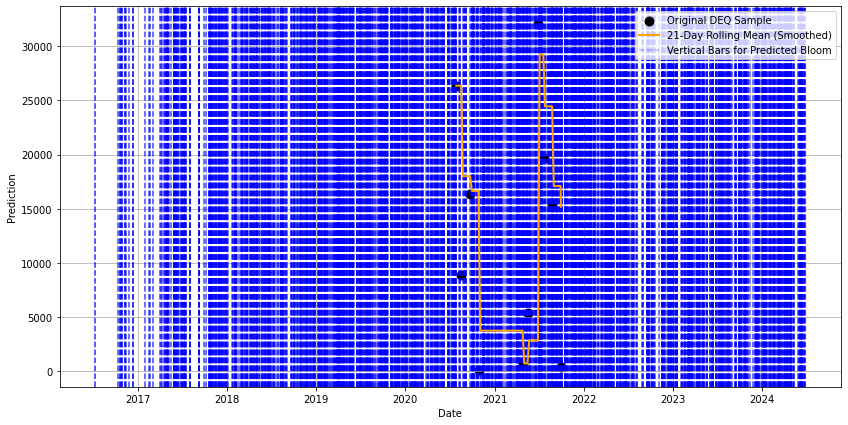

In [151]:
resampled_df = df.resample('D').mean()
resampled_df['exp'] = resampled_df[loc].ewm(alpha=.1, adjust=False).mean()
resampled_df['rolling_mean'] = resampled_df['exp'].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(14, 7))
for date in df7['date']:
    plt.axvline(x=date, color='blue', alpha=0.75,linestyle='--', label='_nolegend_')  # Avoid duplicate legend entries

plt.scatter(resampled_df.index, resampled_df[loc], label='Original DEQ Sample', c='k', s=80, marker='o')
plt.plot(resampled_df.index, resampled_df['rolling_mean'], label=f'{21}-Day Rolling Mean (Smoothed)', color='orange', linewidth=2)
plt.axvline(x=df7['date'].iloc[0], color='blue', alpha=0.25,linestyle='--', label='Vertical Bars for Predicted Bloom')

# plt.title('Rolling Mean of DEQ Counts over North Chowan 2021')
plt.xlabel('Date')
plt.ylabel('Prediction')
plt.legend(loc=1)
plt.grid(True)
# plt.savefig('Figures/roling_northchowan.png', transparent=False, dpi=100, facecolor='white', bbox_inches='tight')
plt.show()


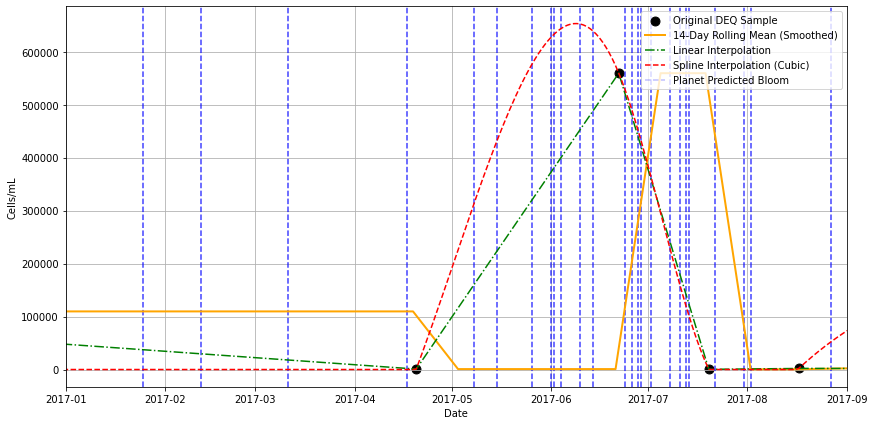

In [195]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

resampled_df = df.resample('D').mean()

# Exponential smoothing + rolling mean (your existing method)
resampled_df['exp'] = resampled_df[loc].ewm(alpha=.5, adjust=False).mean()
resampled_df['rolling_mean'] = resampled_df['exp'].rolling(window=14, min_periods=1).mean()
resampled_df['rolling_mean'] = resampled_df['rolling_mean'].clip(lower=0)   # ensure ≥ 0

# ---- Interpolation Methods ----
# Linear interpolation
resampled_df['linear'] = resampled_df[loc].interpolate(method='linear').clip(lower=0)

# Spline interpolation (cubic spline)
resampled_df['spline'] = resampled_df[loc].interpolate(method='spline', order=3).clip(lower=0)

# ---- Plotting ----
plt.figure(figsize=(14, 7))

# Vertical bars (bloom dates)
df7 = df7.loc[df7['pred'] == 1].drop_duplicates()

for date in df7['date']:
    plt.axvline(x=date, color='blue', alpha=0.75, linestyle='--', label='_nolegend_')

# Original points
plt.scatter(resampled_df.index, resampled_df[loc],
            label='Original DEQ Sample', c='k', s=80, marker='o')

# Rolling mean
plt.plot(resampled_df.index, resampled_df['rolling_mean'],
         label='14-Day Rolling Mean (Smoothed)', color='orange', linewidth=2)

# Linear interpolation
plt.plot(resampled_df.index, resampled_df['linear'],
         label='Linear Interpolation', color='green', linestyle='-.')

# Spline interpolation
plt.plot(resampled_df.index, resampled_df['spline'],
         label='Spline Interpolation (Cubic)', color='red', linestyle='--')


# LOESS (if enabled)
# plt.plot(resampled_df.index, resampled_df['loess'],
#          label='LOESS (Local Regression)', color='purple', linestyle=':')

# Formatting
plt.axvline(x=df7['date'].iloc[0], color='blue', alpha=0.25, linestyle='--',
            label='Planet Predicted Bloom')
plt.xlabel('Date')
plt.ylabel('Cells/mL')
plt.xlim([pd.to_datetime("2017-01-01"), pd.to_datetime("2017-09-01")])

plt.legend(loc=1)
plt.grid(True)
plt.show()


In [196]:
resampled_df= resampled_df.drop(resampled_df.columns[resampled_df.columns.str.startswith('Unnamed:')], axis=1)

dfs = processed_dfs[loc]
dfs['date'] = pd.to_datetime(dfs['date'])
# print(dfs)
resampled_df.index = pd.to_datetime(resampled_df.index)
resampled_df_reset = resampled_df.reset_index()
merged_df = pd.merge(resampled_df_reset, dfs, left_on='DEQ',right_on = 'date', how='inner')
merged_df = merged_df.drop(['date'], axis=1)  
# print(merged_df)
from scipy.stats import mannwhitneyu

group_0 = merged_df.loc[merged_df["pred"] == 0, "spline"].dropna()  # Group with pred = 0
group_1 = merged_df.loc[merged_df["pred"] == 1, "spline"].dropna()  # Group with pred = 1

if len(group_0) > 0 and len(group_1) > 0:
    stat, p_value = mannwhitneyu(group_0, group_1, alternative='two-sided')

    print("Mann-Whitney U Test:")
    print(f"Statistic: {stat}, p-value: {p_value}")
else:
    print("Insufficient data for the test: one of the groups is empty.")


Mann-Whitney U Test:
Statistic: 55021.0, p-value: 4.942740110524424e-09


In [184]:
# Get summary statistics for rolling_mean
# print("Summary Statistics for pred=0:")
# print(df_pred_0['rolling_mean'].describe())
# print("\nSummary Statistics for pred=1:")
# print(df_pred_1['rolling_mean'].describe())


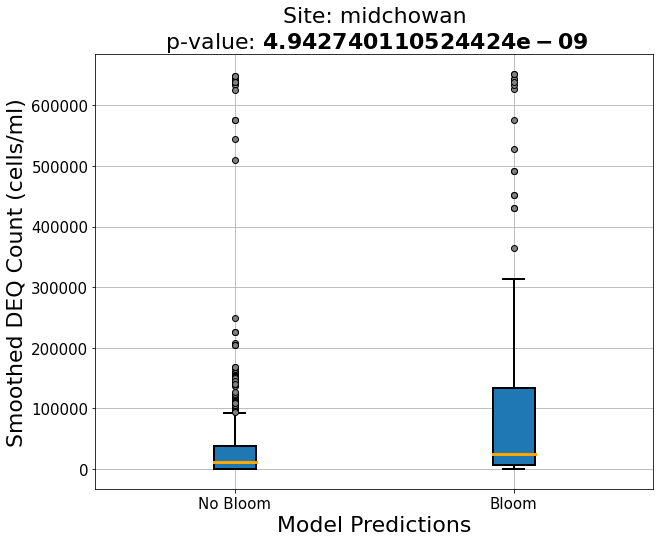

In [198]:
df_pred_0 = merged_df[merged_df['pred'] == 0]
df_pred_1 = merged_df[merged_df['pred'] == 1]


box_colors = ['lightblue', 'lightcoral']

# Create box-and-whisker plots
f, ax = plt.subplots(figsize=(10, 8))
boxplot = ax.boxplot(
    [df_pred_0['spline'].dropna(), df_pred_1['spline'].dropna()],
    labels=['No Bloom', 'Bloom'],
    patch_artist=True,  # Allows filling the boxes with color
    medianprops={'linewidth': 3, 'color': 'orange'},  # Make median thicker
    boxprops={'linewidth': 2},  # Box border thickness
    capprops={'linewidth': 2},  # End caps thickness
    whiskerprops={'linewidth': 2},  # Whisker thickness
    flierprops={'marker': 'o', 'markersize': 6, 'markerfacecolor': 'gray', 'markeredgewidth': 1}  # Outlier styling
)


# Add titles and labels
ax.set_title(f"Site: {loc}\n " + r"p-value: $\bf{" + str(p_value) + "}$", fontsize=22)
ax.set_xlabel('Model Predictions',fontsize=22)
ax.set_ylabel('Smoothed DEQ Count (cells/ml)',fontsize=22)
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.grid(True)
plt.savefig(f'{loc}_bw.png', dpi = 200,  facecolor='white')
plt.show()
